# 🚗 Path Planning – Interpolating Discrete Points

This is where the actual task of **planning a path** begins.

In the real world, we rarely have access to a **continuous set of paths**.  
Instead, we deal with a **limited number of discrete points**, such as waypoints from cone detections or sensor outputs.

Our job is to **connect these discrete points** and generate a smooth and feasible trajectory that the vehicle can follow.

---

## Why Do We Need Interpolation?

Since we cannot drive through isolated points, we must **"connect the dots"** to create a **continuous path**.  
There are different methods for this, and choosing the right one depends on the trade-offs between:
- Accuracy
- Smoothness
- Computation time
- Real-time feasibility

You are encouraged to **explore** these topics online and understand them deeply.  
Your final goal is to **optimize the path**, so analyze each method’s **advantages and disadvantages**.

---

## Suggested Resources

### A) Linear and Quadratic Spline Interpolation
- [Linear & Quadratic Spline Intuition](https://www.youtube.com/watch?v=KLUr1A6vyzs)
- [Quadratic Interpolation Explanation](https://www.youtube.com/watch?v=j_jBK7zJ1vU)
- [Quadratic Spline Derivation](https://www.youtube.com/watch?v=kCPMph3cPA8)

### B) Cubic and Higher-Degree Spline Interpolation
- [Cubic Spline Derivation](https://www.youtube.com/watch?v=wMMjF7kXnWA)
- [Cubic Spline Example](https://www.youtube.com/watch?v=gT7F3TWihvk)

> Try solving the example problem yourself before watching the solution.  
> Now imagine scaling that to **hundreds of points** in real-time path planning!

---

## Assignment

## You are given **four discrete points** in increasing order of x:  
`(x₁, y₁), (x₂, y₂), (x₃, y₃), (x₄, y₄)`

Your task is to:
- **Interpolate these points using Cubic Spline Interpolation**
- **Plot the path obtained.**
- **Do NOT use direct library interpolation functions**
    - You can look up source code online for understanding.
    - But make sure you know **exactly what the code is doing**, step by step.

---

## What to Submit

- Your coded solution (with explanation)
- Analysis of cubic splines vs other interpolation methods
    - Think about smoothness, accuracy, computational cost, and usability in real-time systems

Happy Coding & Exploring!

## 🌟 Optional Assignment

Once you're done with the 4-point cubic spline:

Try writing your **own generic cubic spline interpolation** code for **any number of points (n ≥ 4) taken as input**.

- Again, **do not use `scipy`, `numpy.interp`, or any built-in spline functions**.
- Construct and solve the system of equations manually (or using matrix operations) based on the cubic spline conditions.

This will give you an appreciation of the complexity behind interpolation libraries — and how they are optimized.


In [343]:
import numpy as np
import matplotlib.pyplot as plt

In [344]:
class polynomial:
    def __init__(self, coeffs):
        self.coeffs = coeffs
        self.degree = len(coeffs) - 1
    def __call__(self, x):
        val = 0
        for i in range(self.degree + 1):
            power = self.degree - i
            val += self.coeffs[i] * ((x) ** power)
        return val

    def derivative(self):
        coeffs_derv = []
        for i in range(self.degree):
            power = self.degree - i
            coeffs_derv.append(power * self.coeffs[i])
        return polynomial(coeffs_derv)
    
    def __print__(self):
        print("Polynomial coefficients: ", self.coeffs)

In [345]:
import pandas as pd

df= pd.read_csv('loop_track_waypoints.csv')

In [346]:
df

,Index,X,Y
0,1,5.000000,0.000000
1,2,5.462094,0.704259
2,3,5.785811,1.517218
3,4,5.924263,2.398468
4,5,5.846797,3.292855
5,6,5.543647,4.137331
6,7,5.027707,4.869063
7,8,4.333164,5.433616
8,9,3.511176,5.792052
9,10,2.623221,5.925902


In [347]:
points = []
for i in range(len(df['Index'])):
    points.append([np.array(df['X'])[i], np.array(df['Y'])[i]])

In [348]:
points

[[5.0, 0.0],
 [5.46209423568011, 0.7042590648997543],
 [5.785811449708142, 1.5172184324888387],
 [5.924263414625295, 2.398468438620499],
 [5.846797288821572, 3.2928548865714227],
 [5.543647061880761, 4.137331328745343],
 [5.027707298167441, 4.869062993376477],
 [4.333164230879255, 5.433616082101303],
 [3.5111758245386846, 5.792051776087592],
 [2.6232211206041622, 5.925902205212124],
 [1.7330773908840362, 5.839312810183471],
 [0.8985819522083468, 5.558047102346465],
 [0.1643649911097663, 5.125505684482778],
 [-0.4434038696258703, 4.596344952207277],
 [-0.919508240067778, 4.028628825094072],
 [-1.2790744020607154, 3.475658351704105],
 [-1.5539693065156817, 2.978668227800919],
 [-1.786756462104384, 2.561449749823581],
 [-2.023115923740052, 2.227675473247306],
 [-2.303858633532537, 1.9613034498592832],
 [-2.657723839834204, 1.729986506127524],
 [-3.0960326882127136, 1.490970761641686],
 [-3.609998262432767, 1.1986020032296052],
 [-4.171102255043405, 0.8123220914076376],
 [-4.73449811506959

In [349]:
spline_num = len(points) - 1

In [350]:
x = np.array(df['X'])
y = np.array(df['Y'])

50

In [351]:
import numpy as np

# Compute distances between successive points
dx = np.diff(x)
dy = np.diff(y)
distances = np.sqrt(dx**2 + dy**2)

# Arc-length parameter
t = np.zeros(len(x))
t[1:] = np.cumsum(distances) 

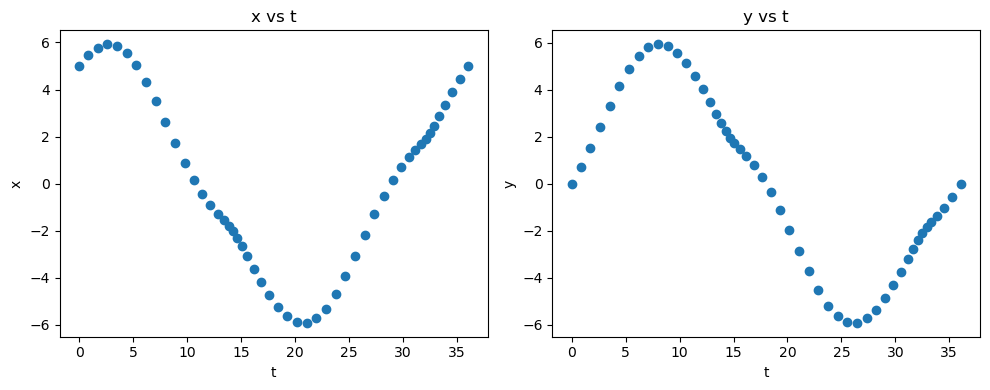

In [352]:
import matplotlib.pyplot as plt
import numpy as np

# Assume x, y, and t are already defined

# Plot x vs t
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(t, x, 'o')
plt.title('x vs t')
plt.xlabel('t')
plt.ylabel('x')

# Plot y vs t
plt.subplot(1, 2, 2)
plt.plot(t, y, 'o')
plt.title('y vs t')
plt.xlabel('t')
plt.ylabel('y')

plt.tight_layout()
plt.show()


In [395]:
y = x
x = t

n = spline_num  # Number of spline segments

h = [x[i+1] - x[i] for i in range(n)]

# Build cyclic tridiagonal system A·M = B
# Setup A matrix and B vector
A = [[0.0 for _ in range(n)] for _ in range(n)]
B = [0.0 for _ in range(n)]

# Set natural boundary conditions: M_0 = 0, M_n = 0
A[0][0] = 1
A[n-1][n-1] = 1
B[0] = 0
B[n-1] = 0

# Set up the interior points for the system
for i in range(1, n-1):
    h_prev = x[i] - x[i-1]
    h_next = x[i+1] - x[i]

    A[i][i-1] = h_prev
    A[i][i]   = 2 * (h_prev + h_next)
    A[i][i+1] = h_next

    B[i] = 6 * ((y[i+1] - y[i]) / h_next - (y[i] - y[i-1]) / h_prev)

# --- Gaussian Elimination Solver for general matrix ---
def gaussian_elimination(A, B):
    n = len(B)
    # Forward Elimination
    for i in range(n):
        # Pivot
        max_row = max(range(i, n), key=lambda r: abs(A[r][i]))
        A[i], A[max_row] = A[max_row], A[i]
        B[i], B[max_row] = B[max_row], B[i]

        # Eliminate
        for j in range(i+1, n):
            factor = A[j][i] / A[i][i]
            for k in range(i, n):
                A[j][k] -= factor * A[i][k]
            B[j] -= factor * B[i]

    # Back Substitution
    M = [0.0] * n
    for i in reversed(range(n)):
        s = sum(A[i][j] * M[j] for j in range(i+1, n))
        M[i] = (B[i] - s) / A[i][i]
    return M

# Deep copy A before passing it in
import copy
M = gaussian_elimination(copy.deepcopy(A), B)

# Compute spline coefficients a, b, c, d
a_x = []
b_x = []
c_x = []
d_x = []

for i in range(n):
    a_x.append(y[i])
    b_x.append((y[i+1] - y[i]) / h[i] - h[i]*(2*M[i] + M[(i+1)%n]) / 6)
    c_x.append(M[i] / 2)
    d_x.append((M[(i+1)%n] - M[i]) / (6 * h[i]))

In [396]:
coeffs_x = np.zeros((spline_num, 4))

In [397]:
for i in range((spline_num)):
    coeffs_x[i][0] = d_x[i]
    coeffs_x[i][1] = c_x[i]
    coeffs_x[i][2] = b_x[i]
    coeffs_x[i][3] = a_x[i] 

In [398]:
splines_x = []
for i in range(spline_num):
    splines_x.append(polynomial(coeffs_x[i]))

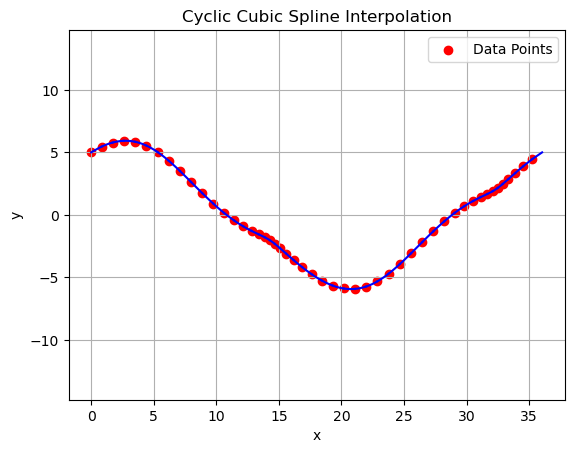

In [399]:
import matplotlib.pyplot as plt

# Plot original points
plt.scatter(x[:n], y[:n], color='red', label='Data Points')

# Plot each spline segment
for i in range(n):
    xi = x[i]
    xi1 = x[i+1]  # next point, x[49+1] = x[0] due to cyclic nature


    xs = [xi + (xi1 - xi) * t / 100.0 for t in range(101)]
    ys = [splines_x[i].__call__(x_val - xi) for x_val in xs]
    plt.plot(xs, ys, color='blue')
    plt.xlim(0, 1)

plt.xlim(0, 1)
plt.title("Cyclic Cubic Spline Interpolation")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()

In [400]:
x = np.array(df['X'])
y = np.array(df['Y'])

In [401]:
x = t

n = spline_num  # Number of spline segments

h = [x[i+1] - x[i] for i in range(n)]

# Setup A matrix and B vector
A = [[0.0 for _ in range(n)] for _ in range(n)]
B = [0.0 for _ in range(n)]

# Set natural boundary conditions: M_0 = 0, M_n = 0
A[0][0] = 1
A[n-1][n-1] = 1
B[0] = 0
B[n-1] = 0

# Set up the interior points for the system
for i in range(1, n-1):
    h_prev = x[i] - x[i-1]
    h_next = x[i+1] - x[i]

    A[i][i-1] = h_prev
    A[i][i]   = 2 * (h_prev + h_next)
    A[i][i+1] = h_next

    B[i] = 6 * ((y[i+1] - y[i]) / h_next - (y[i] - y[i-1]) / h_prev)

# --- Gaussian Elimination Solver for general matrix ---
def gaussian_elimination(A, B):
    n = len(B)
    # Forward Elimination
    for i in range(n):
        # Pivot
        max_row = max(range(i, n), key=lambda r: abs(A[r][i]))
        A[i], A[max_row] = A[max_row], A[i]
        B[i], B[max_row] = B[max_row], B[i]

        # Eliminate
        for j in range(i+1, n):
            factor = A[j][i] / A[i][i]
            for k in range(i, n):
                A[j][k] -= factor * A[i][k]
            B[j] -= factor * B[i]

    # Back Substitution
    M = [0.0] * n
    for i in reversed(range(n)):
        s = sum(A[i][j] * M[j] for j in range(i+1, n))
        M[i] = (B[i] - s) / A[i][i]
    return M

# Deep copy A before passing it in
import copy
M = gaussian_elimination(copy.deepcopy(A), B)

# Compute spline coefficients a, b, c, d
a_y = []
b_y = []
c_y = []
d_y = []

for i in range(n):
    a_y.append(y[i])
    b_y.append((y[i+1] - y[i]) / h[i] - h[i]*(2*M[i] + M[(i+1)%n]) / 6)
    c_y.append(M[i] / 2)
    d_y.append((M[(i+1)%n] - M[i]) / (6 * h[i]))

In [402]:
coeffs_y = np.zeros((spline_num, 4))

In [403]:
for i in range((spline_num)):
    coeffs_y[i][0] = d_y[i]
    coeffs_y[i][1] = c_y[i]
    coeffs_y[i][2] = b_y[i]
    coeffs_y[i][3] = a_y[i] 

In [404]:
splines_y = []
for i in range(spline_num):
    splines_y.append(polynomial(coeffs_y[i]))

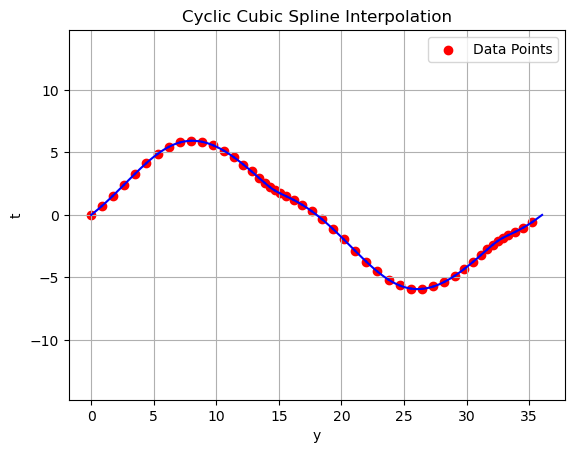

In [405]:
import matplotlib.pyplot as plt

# Plot original points
plt.scatter(x[:n], y[:n], color='red', label='Data Points')

# Plot each spline segment
for i in range(n):
    xi = x[i]
    xi1 = x[i+1]  # next point, x[49+1] = x[0] due to cyclic nature


    xs = [xi + (xi1 - xi) * t / 100.0 for t in range(101)]
    ys = [splines_y[i].__call__(x_val - xi) for x_val in xs]
    plt.plot(xs, ys, color='blue')
    plt.xlim(0, 1)

plt.xlim(0, 1)
plt.title("Cyclic Cubic Spline Interpolation")
plt.xlabel("y")
plt.ylabel("t")
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()

In [406]:
x = np.array(df['X'])
y = np.array(df['Y'])

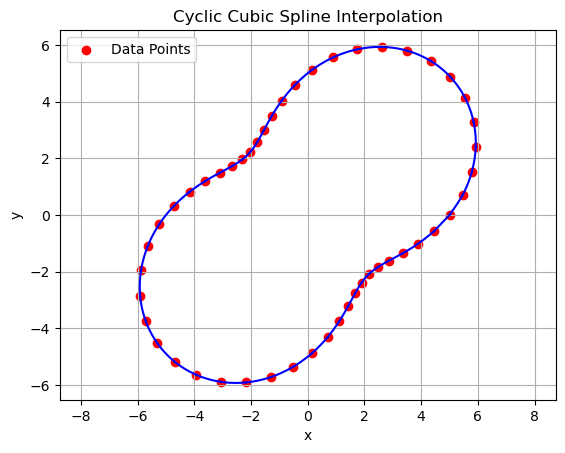

In [407]:
import matplotlib.pyplot as plt

# Plot original points
plt.scatter(x[:n], y[:n], color='red', label='Data Points')

# Plot each spline segment
for i in range(n):
    ti = t[i]
    ti1 = t[i+1]  # next point, x[49+1] = x[0] due to cyclic nature


    ts = [ti + (ti1 - ti) * t / 100.0 for t in range(101)]
    xs = [splines_x[i].__call__(x_val - ti) for x_val in ts]
    ys = [splines_y[i].__call__(y_val - ti) for y_val in ts]
    plt.plot(xs, ys, color='blue')
    plt.xlim(0, 1)

plt.xlim(0, 1)
plt.title("Cyclic Cubic Spline Interpolation")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()